In [1]:
import jax
import sys

import matplotlib.pyplot as plt
import numpy as np

from datasets import get_dataset

sys.path.append("../")
from lib_jax.gd_images import wasserstein_gradient_descent_save
from lib_jax.cccp import cccp
from lib_jax.mmd import target_value_and_grad_riesz_kernel
from lib_jax.mmd_riesz_dc import target_value_and_grad_mmd_riesz1, target_value_and_grad_mmd_riesz2

### Utils Plot

In [2]:
def plot_imgs(imgs, tgt_dataset="MNIST", save=False, method="cccp", n_imgs=6,figsize=(8,3), print_label=True): # 8):
    """
        imgs: ndarray of shape (n_traj, n, d)
    """

    n_traj, n, d = imgs.shape
    
    # fig, axes = plt.subplots(n_imgs, n_traj, figsize=(9, 4.5))
    fig, axes = plt.subplots(n_imgs, n_traj, figsize=figsize)

    fig.subplots_adjust(hspace=0.05, wspace=0.05)

    if tgt_dataset == "CIFAR10":
        mean = [0.4914, 0.4822, 0.4465]
        std = [0.2023, 0.1994, 0.2010]

        imgs = np.array(imgs.reshape(n_traj, n, 3, 32, 32))

        for k in range(3):
            imgs[:,:,k] = imgs[:,:,k] * std[k] + mean[k]
        imgs = np.clip(np.transpose(imgs, (0, 1, 3, 4, 2)), 0, 1)
    elif tgt_dataset in ["MNIST", "FMNIST"]:
        imgs = imgs.reshape(n_traj, n, 28, 28)

    for i in range(n_imgs):
        for j in range(n_traj):
            if tgt_dataset in ["MNIST", "FMNIST"]:
                axes[i, j].imshow(imgs[j, i], "gray")
            else:
                axes[i, j].imshow(imgs[j, i])
            
            axes[i, j].axis('off')

    # if method == "cccp":
    #     plt.suptitle("WCCCP", fontsize=15)
    # elif method == "gd":
    #     plt.suptitle("WGD", fontsize=15)

    if print_label:
        label = "WGD" if method.lower() == "gd" else "WCCCP"
        fig.text(0.02, 0.5, label, va='center', ha='left', rotation=90, fontsize=14)
        fig.subplots_adjust(left=0.08, hspace=0.05, wspace=0.05)
        
    if save:
        plt.savefig("./Figures/trajectories_noise_to_" + tgt_dataset + "_" + method +".pdf", 
                    bbox_inches='tight', pad_inches=0, format="pdf")
    
    plt.show()

### Results MNIST

In [3]:
mnist_gd = np.load("./results/cv_mmd_riesz/particles_mnist_gd.npy")
mnist_cccp = np.load("./results/cv_mmd_riesz/particles_mnist_cccp.npy")

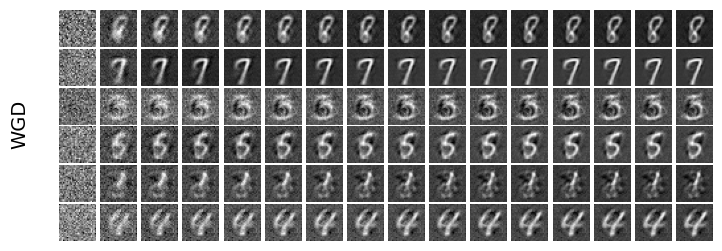

In [4]:
plot_imgs(mnist_gd, method="gd", save=False)

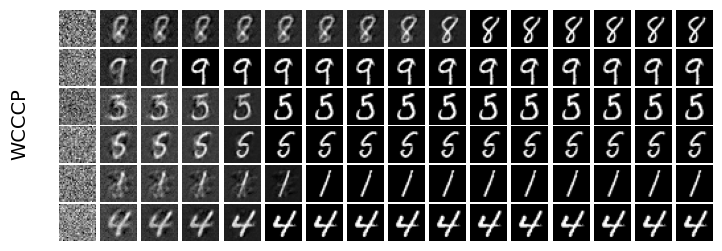

In [5]:
plot_imgs(mnist_cccp, method="cccp", save=False)

In [6]:
mnist_gd = np.load("./results/cv_mmd_riesz_imgs/particles_MNIST_gd.npy") # 18 minutes
mnist_cccp = np.load("./results/cv_mmd_riesz_imgs/particles_MNIST_cccp.npy") # 18 minutes

In [7]:
mnist_cccp.shape

(41, 500, 784)

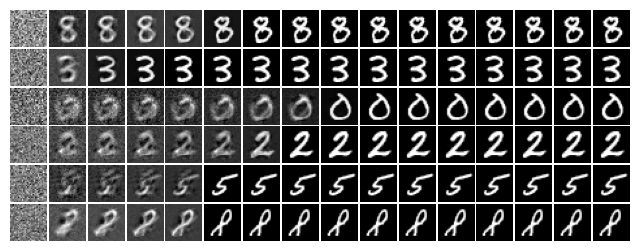

In [8]:
plot_imgs(mnist_gd[:100][::5][:16], method="gd", save=True, print_label=False) 

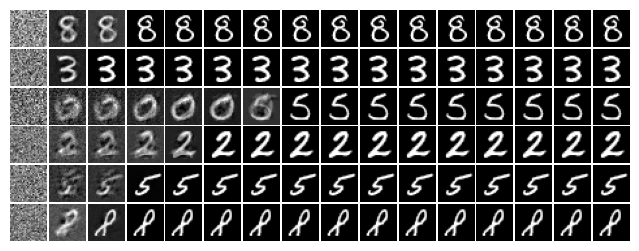

In [9]:
plot_imgs(mnist_cccp[:20][:16], method="cccp", save=True, print_label=False)

In [10]:
loss_gd = np.loadtxt("./results/cv_mmd_riesz_imgs/convergence_MNIST_gd.csv", delimiter=",")
loss_cccp = np.loadtxt("./results/cv_mmd_riesz_imgs/convergence_MNIST_cccp.csv", delimiter=",")

mean_gd = np.mean(loss_gd, axis=0)
std_gd = np.std(loss_gd, axis=0)

mean_cccp = np.mean(loss_cccp, axis=0)
std_cccp = np.std(loss_cccp, axis=0)

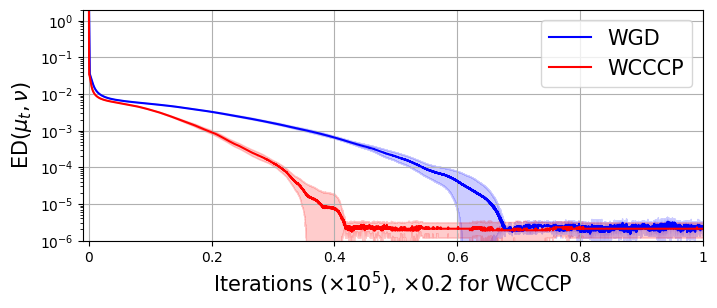

In [11]:
period_subsample = 4

fig, ax = plt.subplots(1, 1, figsize=(8,3))
# plt.plot(loss_gd[::20*1000][:10], c="blue", label="WGD")
# plt.plot(loss_cccp[::4*1000][:10], c="red", label="WCCCP")

x_gd = np.arange(0, len(mean_gd))
x_cccp = np.arange(0, len(mean_cccp))*5

ax.plot(x_gd[::period_subsample], mean_gd[::period_subsample], c="blue", label="WGD")
ax.fill_between(
    x_gd[::period_subsample], 
    mean_gd[::period_subsample]-std_gd[::period_subsample],
    mean_gd[::period_subsample]+std_gd[::period_subsample],
    alpha=0.2, color="blue"
)

ax.plot(x_cccp, mean_cccp, c="red", label="WCCCP")
ax.fill_between(
    x_cccp[::period_subsample], 
    mean_cccp[::period_subsample]-std_cccp[::period_subsample],
    mean_cccp[::period_subsample]+std_cccp[::period_subsample],
    alpha=0.2, color="red"
)

ax.set_xticks([0, 20_000, 40_000, 60_000, 80_000, 100_000, 120_000, 140_000, 160_000, 180_000, 200_000])

ax.set_xticklabels(["0", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$", r"$1$", r"$1.2$", r"$1.4$",
                    r"$1.6$", r"$1.8$", r"$2$"])

ax.set_ylim(1e-6, 2)
ax.set_xlim(-1000, 100_000)

plt.grid(True)
plt.yscale("log")
plt.legend(fontsize=15)
plt.xlabel(r"Iterations ($\times 10^5$), $\times 0.2$ for WCCCP", fontsize=15)
plt.ylabel(r"$\mathrm{ED}(\mu_t,\nu)$", fontsize=15)

plt.savefig("./Figures/Convergence_MMD_MNIST.pdf", format="pdf", bbox_inches="tight")

plt.show()

### Results CIFAR10

In [12]:
cifar10_gd = np.load("./results/cv_mmd_riesz/particles_CIFAR10_gd.npy")
cifar10_cccp = np.load("./results/cv_mmd_riesz/particles_CIFAR10_cccp.npy")

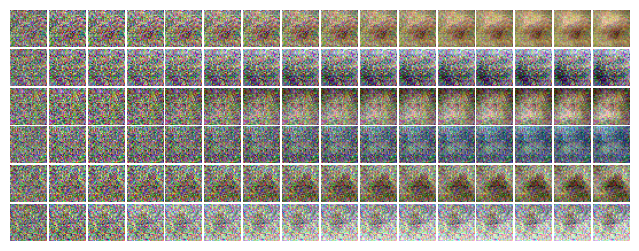

In [13]:
plot_imgs(cifar10_gd[:16], tgt_dataset="CIFAR10", method="gd", save=False, print_label=False)

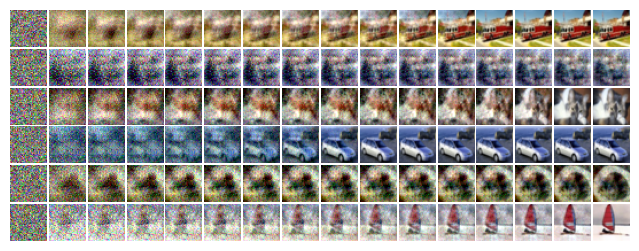

In [14]:
plot_imgs(cifar10_cccp[:16], tgt_dataset="CIFAR10", method="cccp", save=False, print_label=False)

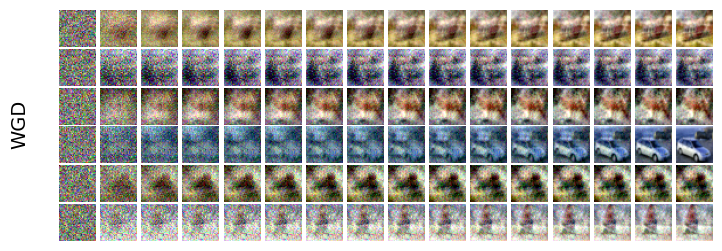

In [15]:
# Every 10K iters, starting from 0 to 160K
plot_imgs(cifar10_gd[::10][:16], tgt_dataset="CIFAR10", method="gd", save=False)

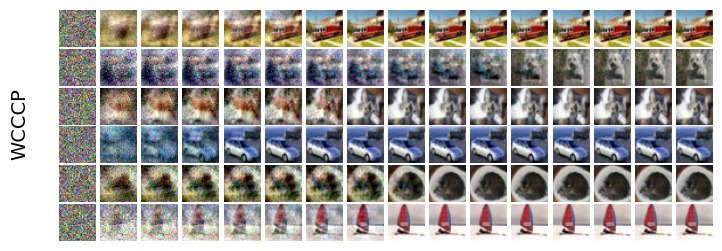

In [16]:
# Every 2K iters, starting from 0 to 32K
plot_imgs(cifar10_cccp[::2][:16], tgt_dataset="CIFAR10", method="cccp", save=False)

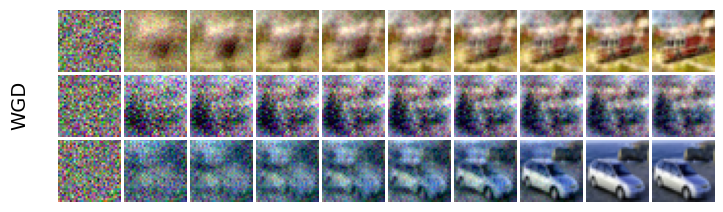

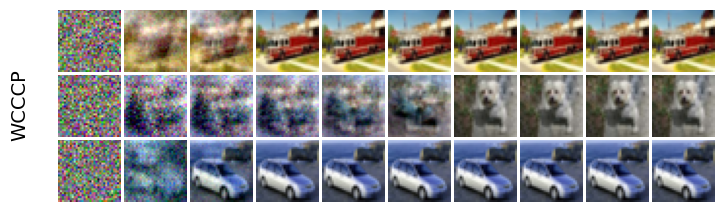

In [17]:
plot_imgs(cifar10_gd[::20][:10,[0, 1, 3]], tgt_dataset="CIFAR10", method="gd", save=False, n_imgs=3, figsize=(8, 2.5))
plot_imgs(cifar10_cccp[::4][:10, [0, 1, 3]], tgt_dataset="CIFAR10", method="cccp", save=False, n_imgs=3, figsize=(8, 2.5))

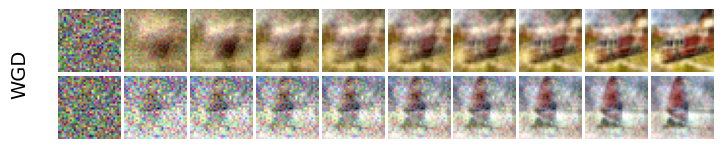

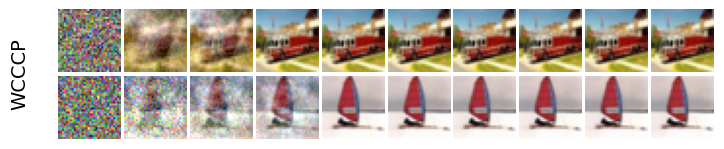

In [18]:
plot_imgs(cifar10_gd[::20][:10,[0, 5]], tgt_dataset="CIFAR10", method="gd", save=True, n_imgs=2, figsize=(8, 1.7))
plot_imgs(cifar10_cccp[::4][:10, [0, 5]], tgt_dataset="CIFAR10", method="cccp", save=True, n_imgs=2, figsize=(8, 1.7))

In [21]:
loss_gd = np.loadtxt("./results/cv_mmd_riesz_imgs/convergence_CIFAR10_gd.csv", delimiter=",")
loss_cccp = np.loadtxt("./results/cv_mmd_riesz_imgs/convergence_CIFAR10_cccp.csv", delimiter=",")

mean_gd = np.mean(loss_gd, axis=0)
std_gd = np.std(loss_gd, axis=0)

mean_cccp = np.mean(loss_cccp, axis=0)
std_cccp = np.std(loss_cccp, axis=0)

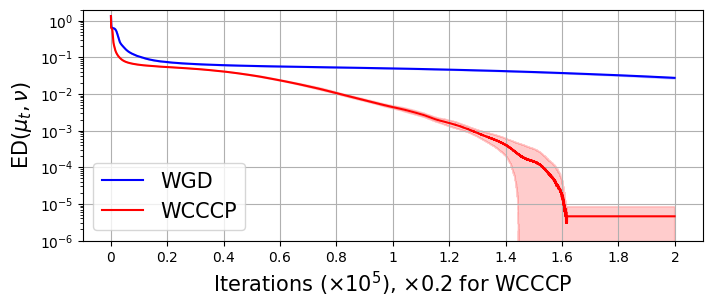

In [22]:
period_subsample = 4

fig, ax = plt.subplots(1, 1, figsize=(8,3))
# plt.plot(loss_gd[::20*1000][:10], c="blue", label="WGD")
# plt.plot(loss_cccp[::4*1000][:10], c="red", label="WCCCP")

x_gd = np.arange(0, len(mean_gd))
x_cccp = np.arange(0, len(mean_cccp))*5

ax.plot(x_gd[::period_subsample], mean_gd[::period_subsample], c="blue", label="WGD")
ax.fill_between(
    x_gd[::period_subsample], 
    mean_gd[::period_subsample]-std_gd[::period_subsample],
    mean_gd[::period_subsample]+std_gd[::period_subsample],
    alpha=0.2, color="blue"
)

ax.plot(x_cccp[::period_subsample], mean_cccp[::period_subsample], c="red", label="WCCCP")
ax.fill_between(
    x_cccp[::period_subsample], 
    mean_cccp[::period_subsample]-std_cccp[::period_subsample],
    mean_cccp[::period_subsample]+std_cccp[::period_subsample],
    alpha=0.2, color="red"
)

ax.set_xticks([0, 20_000, 40_000, 60_000, 80_000, 100_000, 120_000, 140_000, 160_000, 180_000, 200_000])

ax.set_xticklabels(["0", r"$0.2$", r"$0.4$", r"$0.6$", r"$0.8$", r"$1$", r"$1.2$", r"$1.4$",
                    r"$1.6$", r"$1.8$", r"$2$"])

ax.set_ylim(1e-6, 2)

plt.grid(True)
plt.yscale("log")
plt.legend(fontsize=15)
plt.xlabel(r"Iterations ($\times 10^5$), $\times 0.2$ for WCCCP", fontsize=15)
plt.ylabel(r"$\mathrm{ED}(\mu_t,\nu)$", fontsize=15)

plt.savefig("./Figures/Convergence_MMD_CIFAR10.pdf", format="pdf", bbox_inches="tight")

plt.show()